<font face="Garamond">

<center> <font size="7" color="indigo"> Computational Data Mining – Homework 3
<center> <font size="5" color="indigo"> Computational Foundations of Regression (Stability and Scalability)

<center> <img src="https://upload.wikimedia.org/wikipedia/commons/f/fa/Amirkabir-University-of-Technology-Logo.png" width="200"/>


<center> <font size="4" color="darkblue"> Amirkabir University of Technology – Fall 2025


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

<font face="Book Antiqua">

# Part 1: Computational Basics (Small Data)

In [ ]:
np.random.seed(42)

# A = [X  1]
A = np.array([
    [1, 2.0],
    [1, 3.0],
    [1, 4.5],
    [1, 5.5]
])

# y =
y = np.array([
    [3.1],
    [4.9],
    [8.2],
    [10.1]
])

m = len(y)

## • **1.1 – Direct Method (Normal Equations)**

In [ ]:
ATA = A.T @ A

ATy = A.T @ y

theta_normal = np.linalg.inv(ATA) @ ATy

print("Theta (Normal Equations):")
print(theta_normal)

Theta (Normal Equations):
[[-1.04137931]
 [ 2.03103448]]


## • **1.2 – Iterative Method (Batch Gradient Descent)**

In [ ]:
learning_rate = 0.01
n_iterations = 1000

theta_bgd = np.zeros((2, 1))

for i in range(n_iterations):
    gradient = (1/m) * (A.T @ (A @ theta_bgd - y))
    theta_bgd -= learning_rate * gradient

print("Theta (Batch Gradient Descent):")
print(theta_bgd)

Theta (Batch Gradient Descent):
[[-0.55217831]
 [ 1.9146829 ]]


## • **1.3 – Stable Direct Method (SVD Decomposition)**

In [ ]:
U, S, VT = np.linalg.svd(A, full_matrices=False)

S_inv = np.diag(1 / S)

A_pinv = VT.T @ S_inv @ U.T

theta_svd = A_pinv @ y

print("Theta (SVD pseudoinverse):")
print(theta_svd)

Theta (SVD pseudoinverse):
[[-1.04137931]
 [ 2.03103448]]


## • **1.4 – Numerical Stability Analysis**

### **1.4.1 — Parameter Comparison**

In [ ]:
df_theta = pd.DataFrame({
    "Normal_Equations": theta_normal.flatten(),
    "Batch_GD": theta_bgd.flatten(),
    "SVD": theta_svd.flatten()
}, index=["theta_0", "theta_1"])

df_theta

,Normal_Equations,Batch_GD,SVD
theta_0,-1.041379,-0.552178,-1.041379
theta_1,2.031034,1.914683,2.031034


The Normal Equations and SVD produce identical parameters, showing both give the true analytical solution, while Batch Gradient Descent is less accurate here because it has not fully converged under the chosen learning rate and iteration count.

### **1.4.2 — Constructing a Collinear Matrix**

In [ ]:
noise = np.random.rand(m, 1) * 1e-6
A_collinear = np.hstack((A, A[:, [1]] + noise))

In [ ]:
A_collinear

array([[1.        , 2.        , 2.00000016],
       [1.        , 3.        , 3.00000016],
       [1.        , 4.5       , 4.50000006],
       [1.        , 5.5       , 5.50000087]])

### **1.4.3 — Solving with Normal Equations Under Collinearity**

In [ ]:
ATA = A_collinear.T @ A_collinear
theta_normal = np.linalg.inv(ATA) @ A_collinear.T @ y

print("Theta (Normal Equations):")
print(theta_normal)

Theta (Normal Equations):
[[-8.49826247e-01]
 [ 1.35345943e+05]
 [-1.35343933e+05]]


### **1.4.4 — Solving with SVD Under Collinearity**

In [ ]:
theta_svd = np.linalg.pinv(A_collinear) @ y

print("Theta (SVD / pinv):")
print(theta_svd)

Theta (SVD / pinv):
[[-1.08067590e+00]
 [ 1.32866689e+05]
 [-1.32864636e+05]]


### **1.4.5 — Stability Explanation**

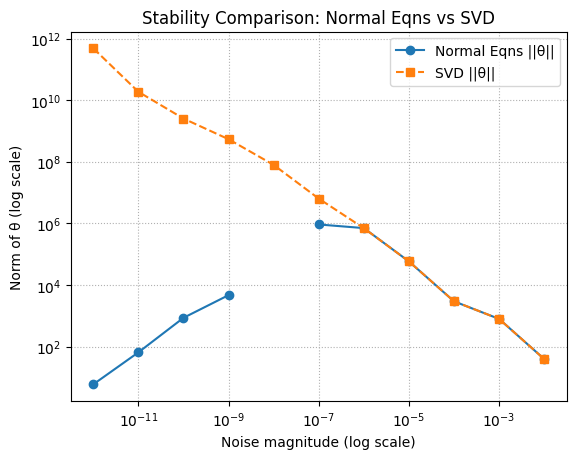

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

A = np.array([
    [1, 2.0],
    [1, 3.0],
    [1, 4.5],
    [1, 5.5]
])
y = np.array([[3.1],[4.9],[8.2],[10.1]])

noise_levels = np.logspace(-12, -2, 11)
norms_normal = []
norms_svd = []

rng = np.random.RandomState(42)

for eps in noise_levels:
    noise = rng.rand(len(y), 1) * eps
    A_col = np.hstack((A, A[:, [1]] + noise))

    try:
        theta_normal = np.linalg.inv(A_col.T @ A_col) @ A_col.T @ y
        norms_normal.append(np.linalg.norm(theta_normal))
    except:
        norms_normal.append(np.nan)

    theta_svd = np.linalg.pinv(A_col) @ y
    norms_svd.append(np.linalg.norm(theta_svd))

plt.loglog(noise_levels, norms_normal, 'o-', label='Normal Eqns ||θ||')
plt.loglog(noise_levels, norms_svd, 's--', label='SVD ||θ||')
plt.xlabel("Noise magnitude (log scale)")
plt.ylabel("Norm of θ (log scale)")
plt.title("Stability Comparison: Normal Eqns vs SVD")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()


<font face="Book Antiqua">

# Part 2: Computational Scalability Analysis (Large Data)

## • **2.1 – Data Loading and Cleaning (Auto MPG Dataset)**

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

column_names = [
    'MPG', 'Cylinders', 'Displacement', 'Horsepower',
    'Weight', 'Acceleration', 'ModelYear', 'Origin', 'CarName'
]

data_mpg = pd.read_csv(
    url,
    names=column_names,
    na_values='?',
    delim_whitespace=True
)

data_mpg = data_mpg.dropna(subset=['Horsepower'])
data_mpg['Horsepower'] = data_mpg['Horsepower'].astype(float)

/tmp/ipython-input-283157417.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_mpg = pd.read_csv(


In [ ]:
data_mpg

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,ModelYear,Origin,CarName
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


## • **2.2 – Matrix Preparation**

### **2.2.1 — Building the Design Matrix**

In [ ]:
y = data_mpg['MPG'].values.reshape(-1, 1)
hp = data_mpg['Horsepower'].values.reshape(-1, 1)

m = hp.shape[0]
A = np.hstack((np.ones((m, 1)), hp))

A[:5], A.shape

(array([[  1., 130.],
        [  1., 165.],
        [  1., 150.],
        [  1., 150.],
        [  1., 140.]]),
 (392, 2))

### **2.2.2 — Normalizing the Matrix Columns**

In [ ]:
hp_mean = hp.mean()
hp_std = hp.std(ddof=0)

hp_norm = (hp - hp_mean) / hp_std
A_norm = np.hstack((np.ones((m, 1)), hp_norm))

A_norm[:5], A_norm.mean(axis=0), A_norm.std(axis=0)

(array([[1.        , 0.66413273],
        [1.        , 1.57459447],
        [1.        , 1.18439658],
        [1.        , 1.18439658],
        [1.        , 0.92426466]]),
 array([ 1.00000000e+00, -4.39274467e-16]),
 array([0., 1.]))

## • **2.3 – Computational Comparison: BGD vs. SGD**

### **2.3.1 — Implementing SGD**

In [ ]:
theta_sgd = np.zeros((2, 1))
learning_rate = 0.01
n_iterations = 5000

cost_sgd = []

for it in range(n_iterations):
    i = np.random.randint(0, m)
    Ai = A_norm[i].reshape(1, -1)
    yi = y[i]

    grad_i = Ai.T @ (Ai @ theta_sgd - yi)
    theta_sgd -= learning_rate * grad_i

    y_pred = A_norm @ theta_sgd
    cost = (1/(2*m)) * np.sum((y_pred - y)**2)
    cost_sgd.append(cost)

theta_sgd

array([[22.78982222],
       [-6.59270376]])

### **2.3.2 — Implementing BGD**

In [ ]:
theta_bgd = np.zeros((2, 1))
learning_rate = 0.01
n_iterations_bgd = 1000

cost_bgd = []

for it in range(n_iterations_bgd):
    grad = A_norm.T @ (A_norm @ theta_bgd - y) / m
    theta_bgd -= learning_rate * grad

    y_pred = A_norm @ theta_bgd
    cost = (1/(2*m)) * np.sum((y_pred - y)**2)
    cost_bgd.append(cost)

theta_bgd

array([[23.44490618],
       [-6.06761045]])

### **2.3.3 — Tracking the Cost Function**

In [ ]:
print("Final BGD cost:", cost_bgd[-1])
print("Final SGD cost:", cost_sgd[-1])

min_len = min(len(cost_bgd), len(cost_sgd))
cost_bgd_plot = cost_bgd[:min_len]
cost_sgd_plot = cost_sgd[:min_len]

len(cost_bgd_plot), len(cost_sgd_plot)

Final BGD cost: 11.971832015876284
Final SGD cost: 12.324786524945141


(1000, 1000)

## • **2.4 – Scalability Analysis**

### **2.4.1 — Convergence Plot (Iterations vs. Cost)**

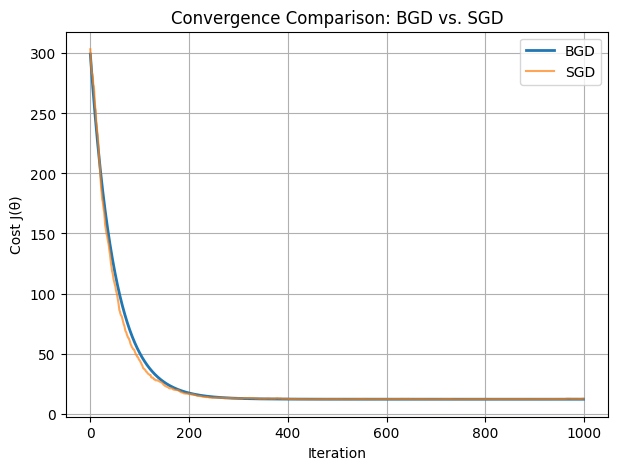

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(cost_bgd_plot, label='BGD', linewidth=2)
plt.plot(cost_sgd_plot, label='SGD', alpha=0.7)

plt.xlabel("Iteration")
plt.ylabel("Cost J(θ)")
plt.title("Convergence Comparison: BGD vs. SGD")
plt.legend()
plt.grid(True)
plt.show()

<font face="Book Antiqua">

# Part 3: Application — Nonlinear Regression

## **• 3.1 – Implementing Polynomial Regression**

### **3.1.1 — Returning to the Auto MPG Dataset**

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG','Cylinders','Displacement','Horsepower',
                'Weight','Acceleration','ModelYear','Origin','CarName']
data_mpg = pd.read_csv(url, names=column_names,
                       na_values='?', delim_whitespace=True)
data_mpg = data_mpg.dropna(subset=['Horsepower'])
data_mpg['Horsepower'] = data_mpg['Horsepower'].astype(float)

/tmp/ipython-input-2572292205.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_mpg = pd.read_csv(url, names=column_names,


### **3.1.2 — Constructing the Polynomial Design Matrix**

In [ ]:
x = data_mpg['Horsepower'].values.reshape(-1,1)
x2 = (data_mpg['Horsepower']**2).values.reshape(-1,1)
y = data_mpg['MPG'].values.reshape(-1,1)

A_poly = np.hstack([np.ones_like(x), x, x2])

scaler = StandardScaler()
A_poly[:,1:] = scaler.fit_transform(A_poly[:,1:])

print("A_poly shape:", A_poly.shape)

A_poly shape: (392, 3)


### **3.1.3 — Fitting the Polynomial Model Using SGD**

In [ ]:
def sgd_poly(A, y, learning_rate=0.01, n_iterations=5000):
    m, n = A.shape
    theta = np.zeros((n,1))
    cost_log = []

    for t in range(n_iterations):
        i = np.random.randint(0, m)
        Ai = A[i:i+1]
        yi = y[i:i+1]

        error = Ai @ theta - yi

        grad = Ai.T @ error

        theta -= learning_rate * grad

        if t % 10 == 0:
            cost = (1/(2*m)) * np.sum((A @ theta - y)**2)
            cost_log.append(cost)

    return theta, cost_log

theta_poly, cost_poly = sgd_poly(A_poly, y)
print("theta_poly:\n", theta_poly)

theta_poly:
 [[ 23.49128331]
 [-11.09044868]
 [  5.26662282]]


### **3.1.4 — Plotting the Polynomial Regression Curve**

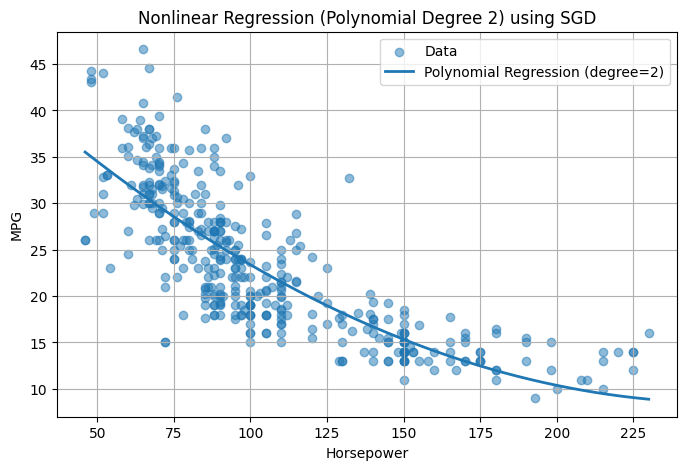

In [ ]:
x_plot = np.linspace(data_mpg['Horsepower'].min(),
                     data_mpg['Horsepower'].max(), 300).reshape(-1,1)

x_plot2 = x_plot**2
A_plot = np.hstack([np.ones_like(x_plot),
                    scaler.transform(np.hstack([x_plot, x_plot2]))])

y_pred_curve = A_plot @ theta_poly

plt.figure(figsize=(8,5))
plt.scatter(data_mpg['Horsepower'], data_mpg['MPG'], alpha=0.5, label="Data")
plt.plot(x_plot, y_pred_curve, linewidth=2, label="Polynomial Regression (degree=2)")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Nonlinear Regression (Polynomial Degree 2) using SGD")
plt.legend()
plt.grid(True)
plt.show()